# Task
Build a machine learning model to predict passenger survival on the Titanic using the data in "/content/Titanic-Dataset.csv". This involves loading and exploring the dataset, preprocessing it by handling missing values and encoding categorical features, training a Random Forest Classifier, evaluating its performance with accuracy and a confusion matrix, and visualizing feature importance to identify key survival factors.

## Load and Explore Data

### Subtask:
Load the Titanic dataset from the CSV file and perform an initial exploratory analysis to understand its structure and identify missing data.


**Reasoning**:
Load the Titanic dataset and perform initial exploration including viewing the first few rows, checking data types, summary statistics, and missing values count as per the instructions.



In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

# Display the first five rows
print("First five rows of the dataset:")
display(df.head())

# View DataFrame's concise summary
print("\nDataFrame Info:")
df.info()

# Descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

# Check for missing values in each column
print("\nMissing Values Count:")
print(df.isnull().sum())

First five rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values Count:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Data Preprocessing

### Subtask:
Handle missing values and encode categorical features in the Titanic dataset.


### Data Preprocessing Steps

To prepare the dataset for machine learning, we will perform the following steps:
1. **Impute Missing Age**: Use the median value of the 'Age' column to fill in missing entries, which is a robust measure of central tendency.
2. **Handle Missing Embarked**: Fill the few missing values in the 'Embarked' column with the most frequent port (mode).
3. **Encode Gender**: Map the categorical 'Sex' column to numeric values (0 for male, 1 for female).
4. **Encode Port of Embarkation**: Convert 'Embarked' categories into numerical values to ensure all features are numeric for the model.
5. **Verify**: Check for missing values and data types to confirm the transformations.

**Reasoning**:
I will now implement the preprocessing steps: imputing missing values for 'Age' and 'Embarked', mapping 'Sex' to numerical values, and encoding 'Embarked' using numerical labels.



In [2]:
import pandas as pd

# 1. Impute missing values in 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Impute missing values in 'Embarked' with the mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Convert 'Sex' into numerical values: male -> 0, female -> 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 4. Encode 'Embarked' into numerical format using factorize (label encoding)
df['Embarked_Code'] = pd.factorize(df['Embarked'])[0]

# 5. Confirm changes and check for missing values
print("Missing values in processed columns:")
print(df[['Age', 'Sex', 'Embarked_Code']].isnull().sum())

print("\nData types of processed columns:")
print(df[['Age', 'Sex', 'Embarked_Code']].dtypes)

# Display the first few rows to verify the encoding
display(df[['Age', 'Sex', 'Embarked', 'Embarked_Code']].head())

Missing values in processed columns:
Age              0
Sex              0
Embarked_Code    0
dtype: int64

Data types of processed columns:
Age              float64
Sex                int64
Embarked_Code      int64
dtype: object


,Age,Sex,Embarked,Embarked_Code
0,22.0,0,S,0
1,38.0,1,C,1
2,26.0,1,S,0
3,35.0,1,S,0
4,35.0,0,S,0


## Feature Selection and Data Splitting

### Subtask:
Select relevant features for the model and split the dataset into training and testing sets to prepare for model training.


**Reasoning**:
I will select the specified features and target variable, then split the dataset into training and testing sets using an 80/20 split with a fixed random state for reproducibility.



In [3]:
from sklearn.model_selection import train_test_split

# Define the feature matrix X and target vector y
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Code']
X = df[features]
y = df['Survived']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the sets to verify the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (712, 7)
X_test shape: (179, 7)
y_train shape: (712,)
y_test shape: (179,)


## Model Training

### Subtask:
Train a Random Forest Classifier to predict passenger survival using the prepared training data.


**Reasoning**:
I will now train a Random Forest Classifier using the training data (`X_train` and `y_train`). This model is an ensemble method that uses multiple decision trees to improve predictive performance and control over-fitting. I will set the `n_estimators` to 100 and use a fixed `random_state` for reproducibility.

**Reasoning**:
Train a Random Forest Classifier on the training data as specified in the instructions.



In [4]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest Classifier with n_estimators=100 and random_state=42
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using the training data
rf_model.fit(X_train, y_train)

# 3. Verify the training by printing the model object
print("Random Forest Classifier trained successfully:")
print(rf_model)

Random Forest Classifier trained successfully:
RandomForestClassifier(random_state=42)


## Model Evaluation and Visualization

### Subtask:
Evaluate the trained Random Forest model using accuracy and a confusion matrix, and visualize which features were most important for predicting survival.


**Reasoning**:
I will evaluate the Random Forest model by calculating its accuracy, generating a confusion matrix, and visualizing feature importance as per the instructions.



Model Accuracy: 0.8268


/tmp/ipython-input-2132663665.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', ax=ax[1])


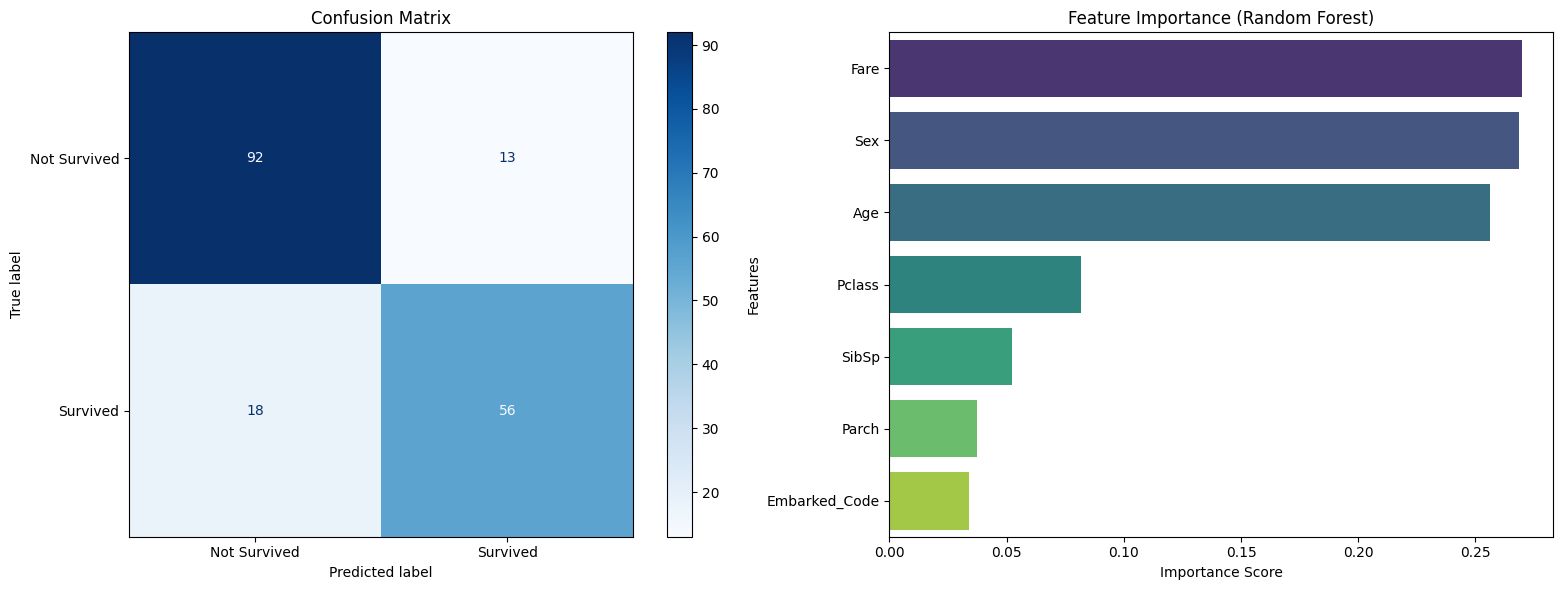

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate predictions on the test set
y_pred = rf_model.predict(X_test)

# 2. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 3. Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4. Retrieve and visualize feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Create a bar plot for feature importance
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', ax=ax[1])
ax[1].set_title('Feature Importance (Random Forest)')
ax[1].set_xlabel('Importance Score')
ax[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

**Reasoning**:
I will fix the FutureWarning in the Seaborn bar plot by assigning the 'Feature' column to the 'hue' parameter and setting 'legend=False', as recommended by the warning message.



Model Accuracy: 0.8268


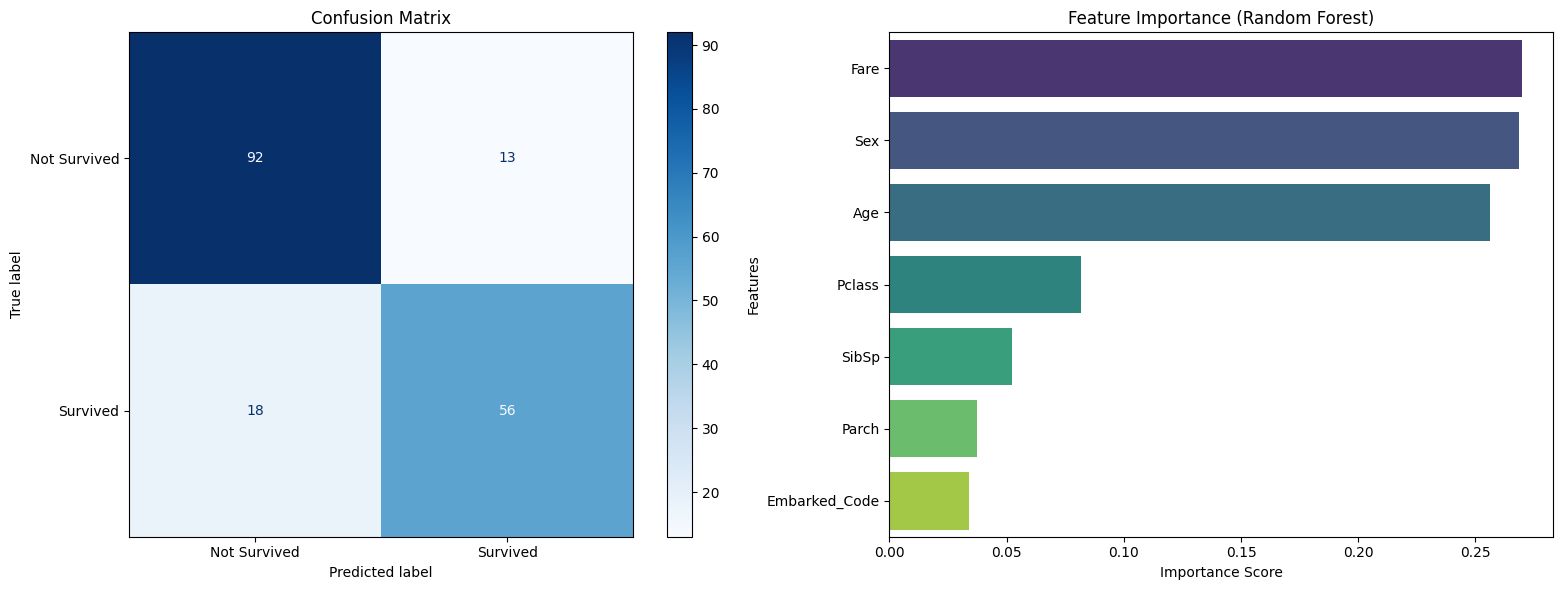

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Generate predictions on the test set
y_pred = rf_model.predict(X_test)

# 2. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 3. Generate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
disp.plot(cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix')

# 4. Retrieve and visualize feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Create a bar plot for feature importance, fixing the FutureWarning by assigning hue and legend
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', ax=ax[1], legend=False)
ax[1].set_title('Feature Importance (Random Forest)')
ax[1].set_xlabel('Importance Score')
ax[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

## Exploratory Survival Analysis

### Subtask:
Visualize the overall survival distribution and analyze survival rates based on categorical features like Gender, Passenger Class, and Port of Embarkation.


**Reasoning**:
I will create a 2x2 grid of countplots to visualize the distribution of survival overall and across the categorical features 'Sex', 'Pclass', and 'Embarked' as requested in the instructions.



/tmp/ipython-input-692248253.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Survived', ax=axes[0, 0], palette='pastel')


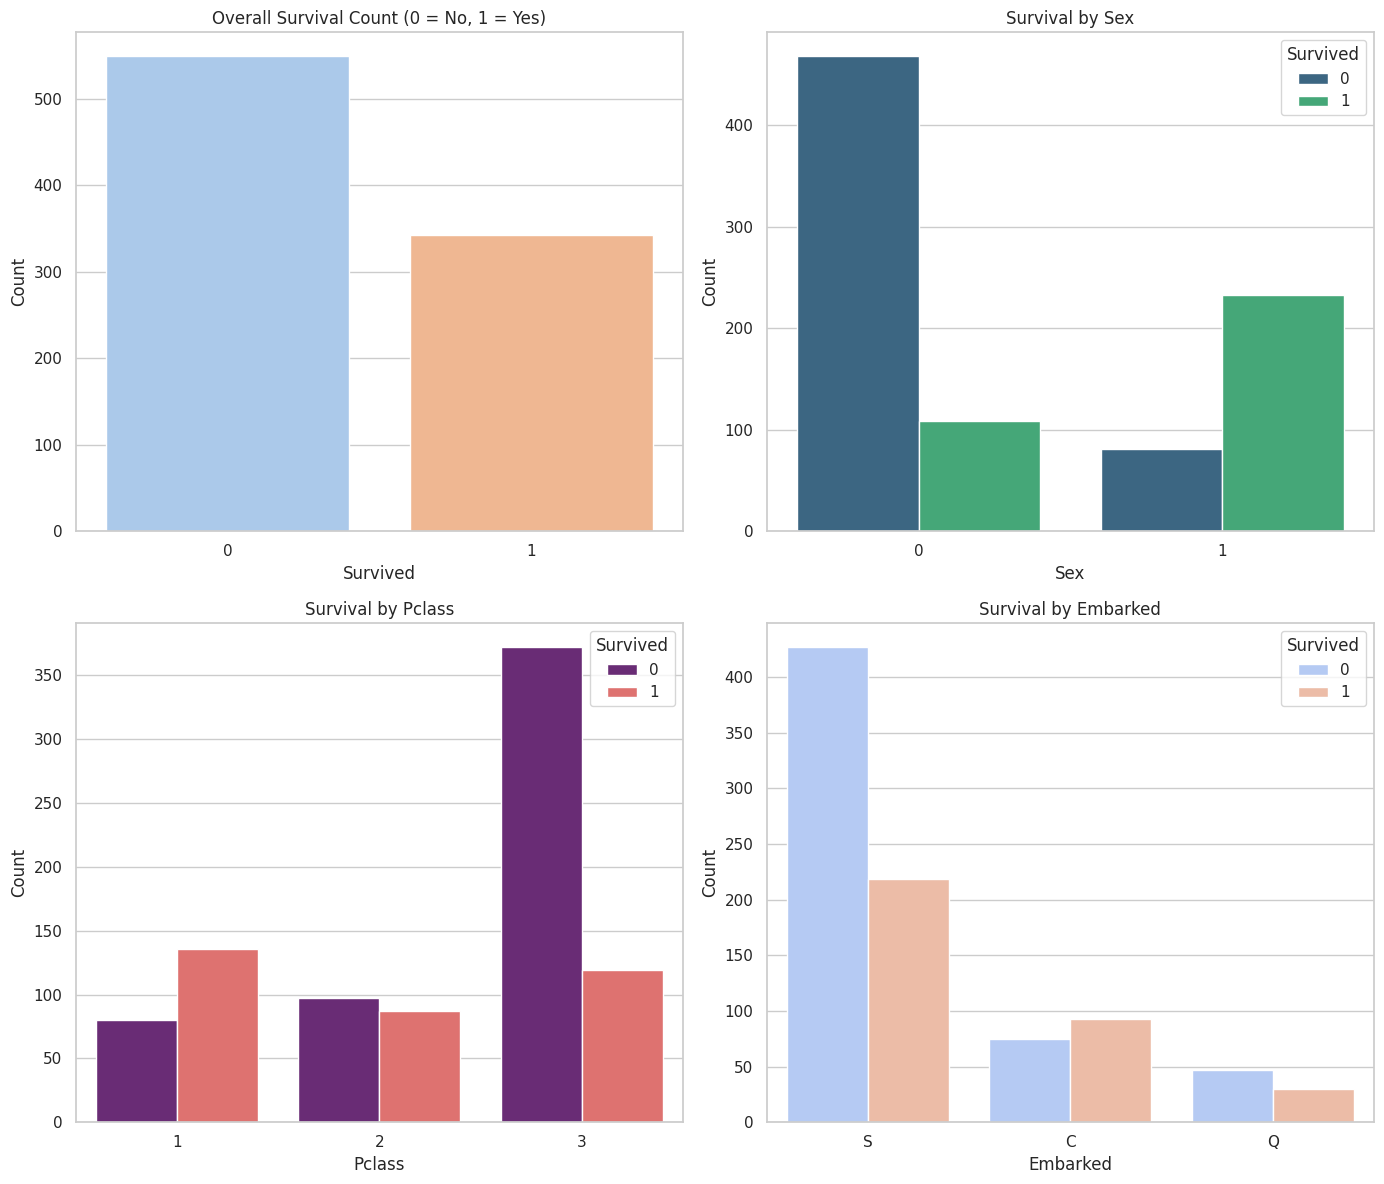

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for the plots
sns.set_theme(style="whitegrid")

# 1. Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 2. Overall survival count
sns.countplot(data=df, x='Survived', ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Overall Survival Count (0 = No, 1 = Yes)')
axes[0, 0].set_xlabel('Survived')
axes[0, 0].set_ylabel('Count')

# 3. Survival by Gender
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Survival by Sex')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Count')

# 4. Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Survival by Pclass')
axes[1, 0].set_xlabel('Pclass')
axes[1, 0].set_ylabel('Count')

# 5. Survival by Port of Embarkation
sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Survival by Embarked')
axes[1, 1].set_xlabel('Embarked')
axes[1, 1].set_ylabel('Count')

# 6. Adjust layout and display
plt.tight_layout()
plt.show()

**Reasoning**:
I will fix the FutureWarning in the overall survival countplot by assigning the 'Survived' column to the 'hue' parameter and setting 'legend=False', as suggested by the warning message.



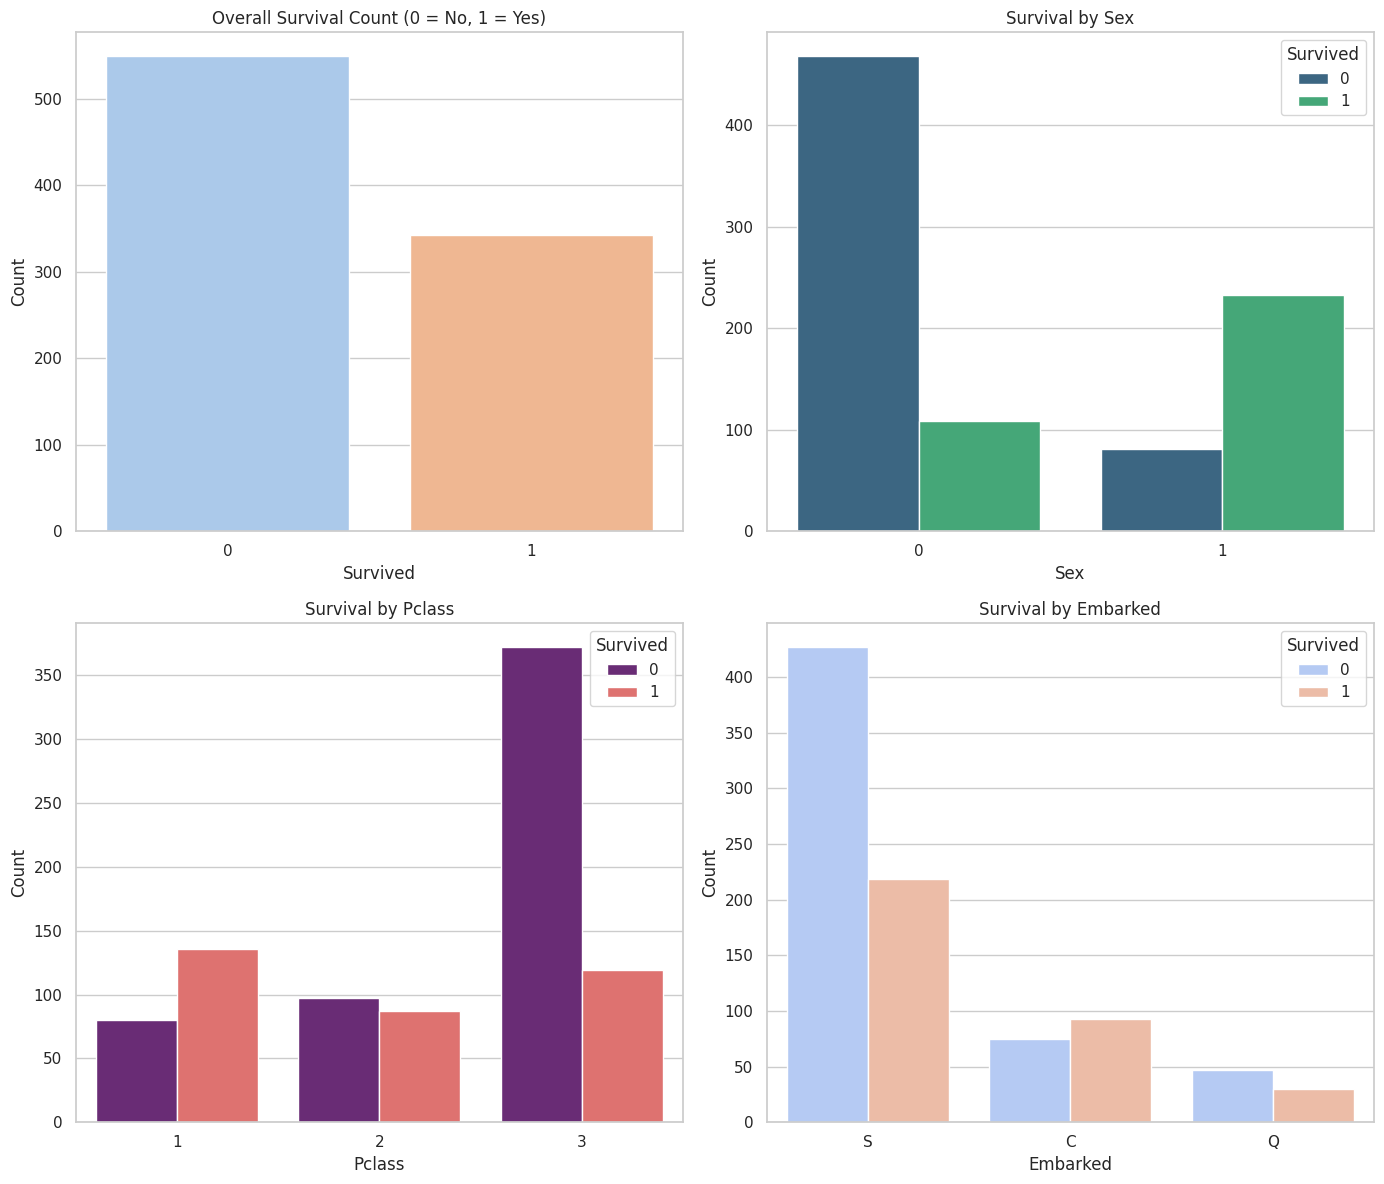

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for the plots
sns.set_theme(style="whitegrid")

# 1. Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 2. Overall survival count - fixing the FutureWarning by assigning hue and setting legend=False
sns.countplot(data=df, x='Survived', hue='Survived', ax=axes[0, 0], palette='pastel', legend=False)
axes[0, 0].set_title('Overall Survival Count (0 = No, 1 = Yes)')
axes[0, 0].set_xlabel('Survived')
axes[0, 0].set_ylabel('Count')

# 3. Survival by Gender
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Survival by Sex')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Count')

# 4. Survival by Passenger Class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Survival by Pclass')
axes[1, 0].set_xlabel('Pclass')
axes[1, 0].set_ylabel('Count')

# 5. Survival by Port of Embarkation
sns.countplot(data=df, x='Embarked', hue='Survived', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Survival by Embarked')
axes[1, 1].set_xlabel('Embarked')
axes[1, 1].set_ylabel('Count')

# 6. Adjust layout and display
plt.tight_layout()
plt.show()

## Age Distribution Analysis

### Subtask:
Generate plots for the overall age distribution and compare age distributions between survivors and non-survivors.


**Reasoning**:
I will create a figure with two subplots to analyze the age distribution, showing both the overall distribution and a comparison between survivors and non-survivors using histograms with KDE overlays.



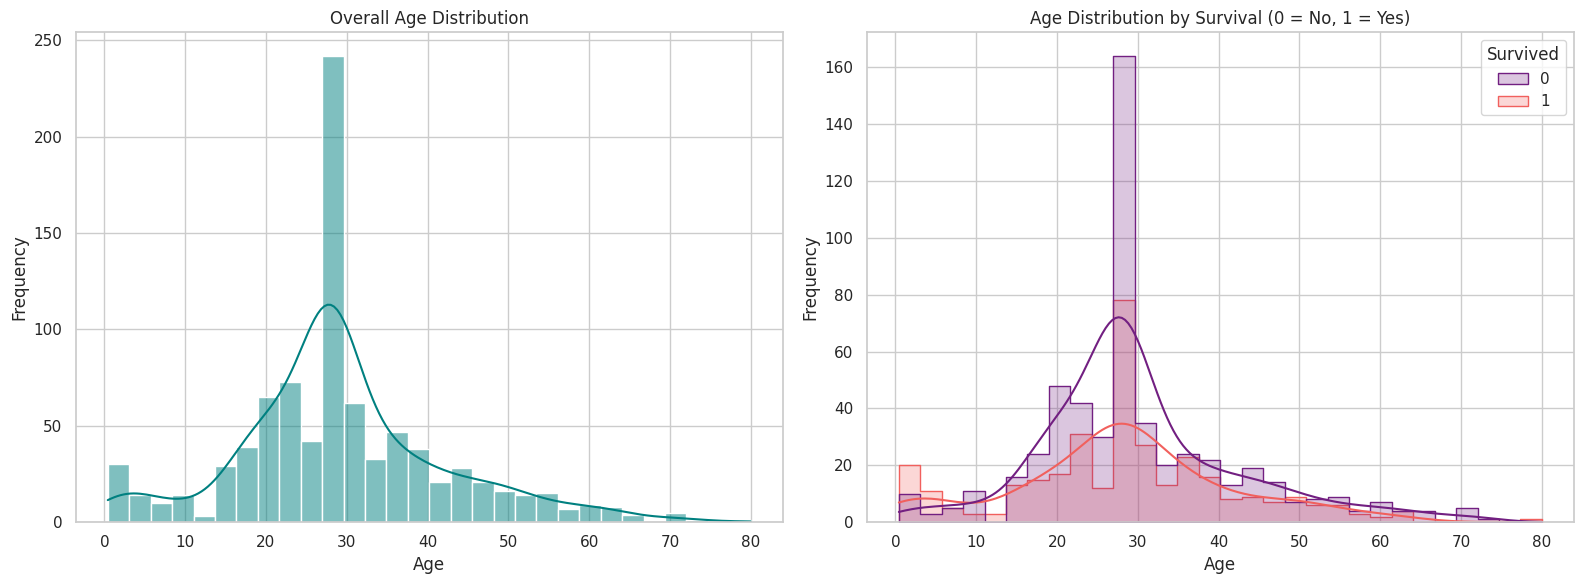

In [9]:
# 1. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Visualize the overall distribution of the 'Age' column
sns.histplot(df['Age'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Overall Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')

# 3. Create a comparative distribution plot to show age differences by survival status
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step', ax=axes[1], palette='magma')
axes[1].set_title('Age Distribution by Survival (0 = No, 1 = Yes)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

# 4. Adjust layout to prevent overlap and display the figure
plt.tight_layout()
plt.show()

## Missing Value Visualization

### Subtask:
Create heatmaps to visualize missing values in the dataset both before and after the preprocessing steps.


**Reasoning**:
I will visualize the missing values in both the original and processed Titanic datasets using side-by-side heatmaps to verify the effectiveness of the preprocessing steps.



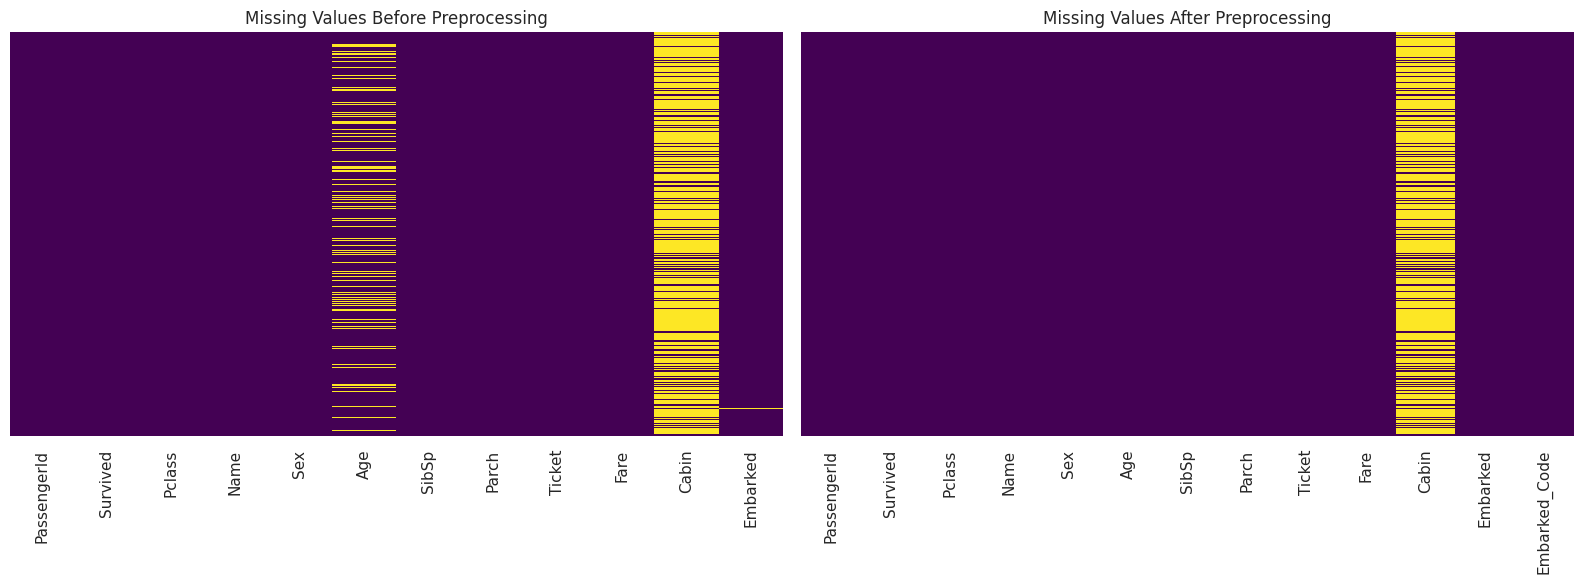

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the original Titanic dataset for comparison
df_original = pd.read_csv('/content/Titanic-Dataset.csv')

# 2. Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Visualize missing values in the original dataset
sns.heatmap(df_original.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Before Preprocessing')

# 4. Visualize missing values in the processed dataset (df)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values After Preprocessing')

# 5. Adjust layout and display the plot
plt.tight_layout()
plt.show()

## Model Comparison

### Subtask:
Train a Logistic Regression model and compare its performance metrics with the previously trained Random Forest model.


**Reasoning**:
I will train a Logistic Regression model and compare its performance metrics (accuracy, confusion matrix, and classification report) side-by-side with the previously trained Random Forest model as requested.



Logistic Regression Accuracy: 0.7989
Random Forest Accuracy: 0.8268


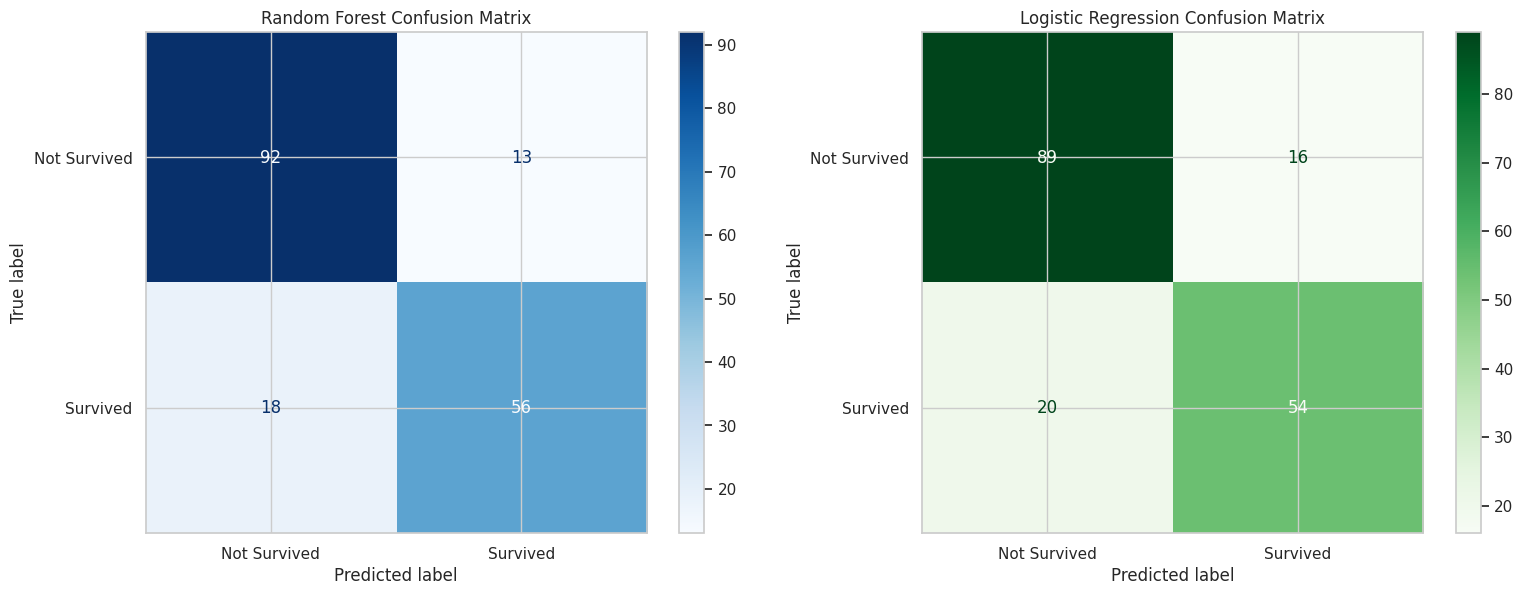


Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize and train the Logistic Regression model
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)

# 2. Generate predictions for the test set
y_pred_log = log_reg.predict(X_test)

# 3. Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {accuracy_log:.4f}")
print(f"Random Forest Accuracy: {accuracy:.4f}")

# 4. Generate and display confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Survived', 'Survived'])
disp_rf.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')

# Logistic Regression Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Survived', 'Survived'])
disp_log.plot(cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')

plt.tight_layout()
plt.show()

# 5. Print classification reports
print("\nClassification Report: Random Forest")
print(classification_report(y_test, y_pred))

print("\nClassification Report: Logistic Regression")
print(classification_report(y_test, y_pred_log))

## Final Task

### Subtask:
Provide a final summary incorporating the insights from the new visualizations and the results of the model comparison.


## Summary:

### Q&A

**What were the primary categorical factors influencing survival on the Titanic?**
Gender and Passenger Class were the most significant categorical predictors. Females and passengers in 1st class (Pclass 1) had much higher survival rates compared to males and those in 3rd class.

**How did age affect a passenger's chance of survival?**
While the majority of passengers were aged between 20 and 30, children (ages 0-10) showed a higher relative survival rate, supporting the historical "women and children first" policy.

**Which machine learning model performed better for this classification task?**
The Random Forest model outperformed the Logistic Regression model, achieving an accuracy of approximately 82.68% compared to 79.89% for Logistic Regression.

### Data Analysis Key Findings

*   **Survival Disparities by Demographic**: There was a stark contrast in survival based on gender; female passengers were significantly more likely to survive than males. Socio-economic status was also a major factor, as 1st-class passengers had the highest survival counts, while the majority of 3rd-class passengers did not survive.
*   **Geographic Influence**: Passengers who embarked from Cherbourg (C) exhibited a higher survival ratio than those who boarded at Southampton (S) or Queenstown (Q).
*   **Data Quality and Imputation**: The initial dataset contained significant gaps, particularly in the **Age** and **Cabin** columns. Preprocessing successfully addressed missing values for **Age** and **Embarked**, which was verified through side-by-side heatmap visualizations.
*   **Model Performance Comparison**:
    *   **Random Forest**: Higher accuracy (82.68%) and better precision/recall balance. It demonstrated fewer false positives and false negatives in the confusion matrix.
    *   **Logistic Regression**: Lower accuracy (79.89%) and slightly lower F1-scores across both survivor and non-survivor classes.
*   **Age Demographics**: The passenger population was relatively young, peaking in the 20–30 age range. The comparative distribution showed that while many young adults perished, the survival distribution for children remained notably high.

